2026-05-14 14:01:25,690 - INFO - Loading data from processed_data\M1_Hand_Knob_ML_Features.csv...
2026-05-14 14:01:25,712 - INFO - Target distribution:
target
rest    37
move    37
Name: count, dtype: int64
2026-05-14 14:01:25,722 - INFO - Data loaded: 74 samples, 6 features.
2026-05-14 14:01:25,725 - INFO - Checking for GPU availability...
2026-05-14 14:01:25,734 - INFO - Could not check GPU. Using CPU.
2026-05-14 14:01:25,737 - INFO - Starting analysis for: M1_Hand_Knob_Bands
2026-05-14 14:01:25,748 - INFO - Training set size: 59, Test set size: 15
2026-05-14 14:01:25,751 - INFO - Training XGBoost model on CPU...
2026-05-14 14:01:25,951 - INFO - Performing Cross-Validation...
2026-05-14 14:01:33,875 - INFO - --- Results for M1_Hand_Knob_Bands ---
2026-05-14 14:01:33,878 - INFO - Accuracy: 0.667
2026-05-14 14:01:33,880 - INFO - Precision: 0.625
2026-05-14 14:01:33,882 - INFO - Recall: 0.714
2026-05-14 14:01:33,885 - INFO - F1: 0.667
2026-05-14 14:01:33,887 - INFO - Auc: 0.857
2026-05-

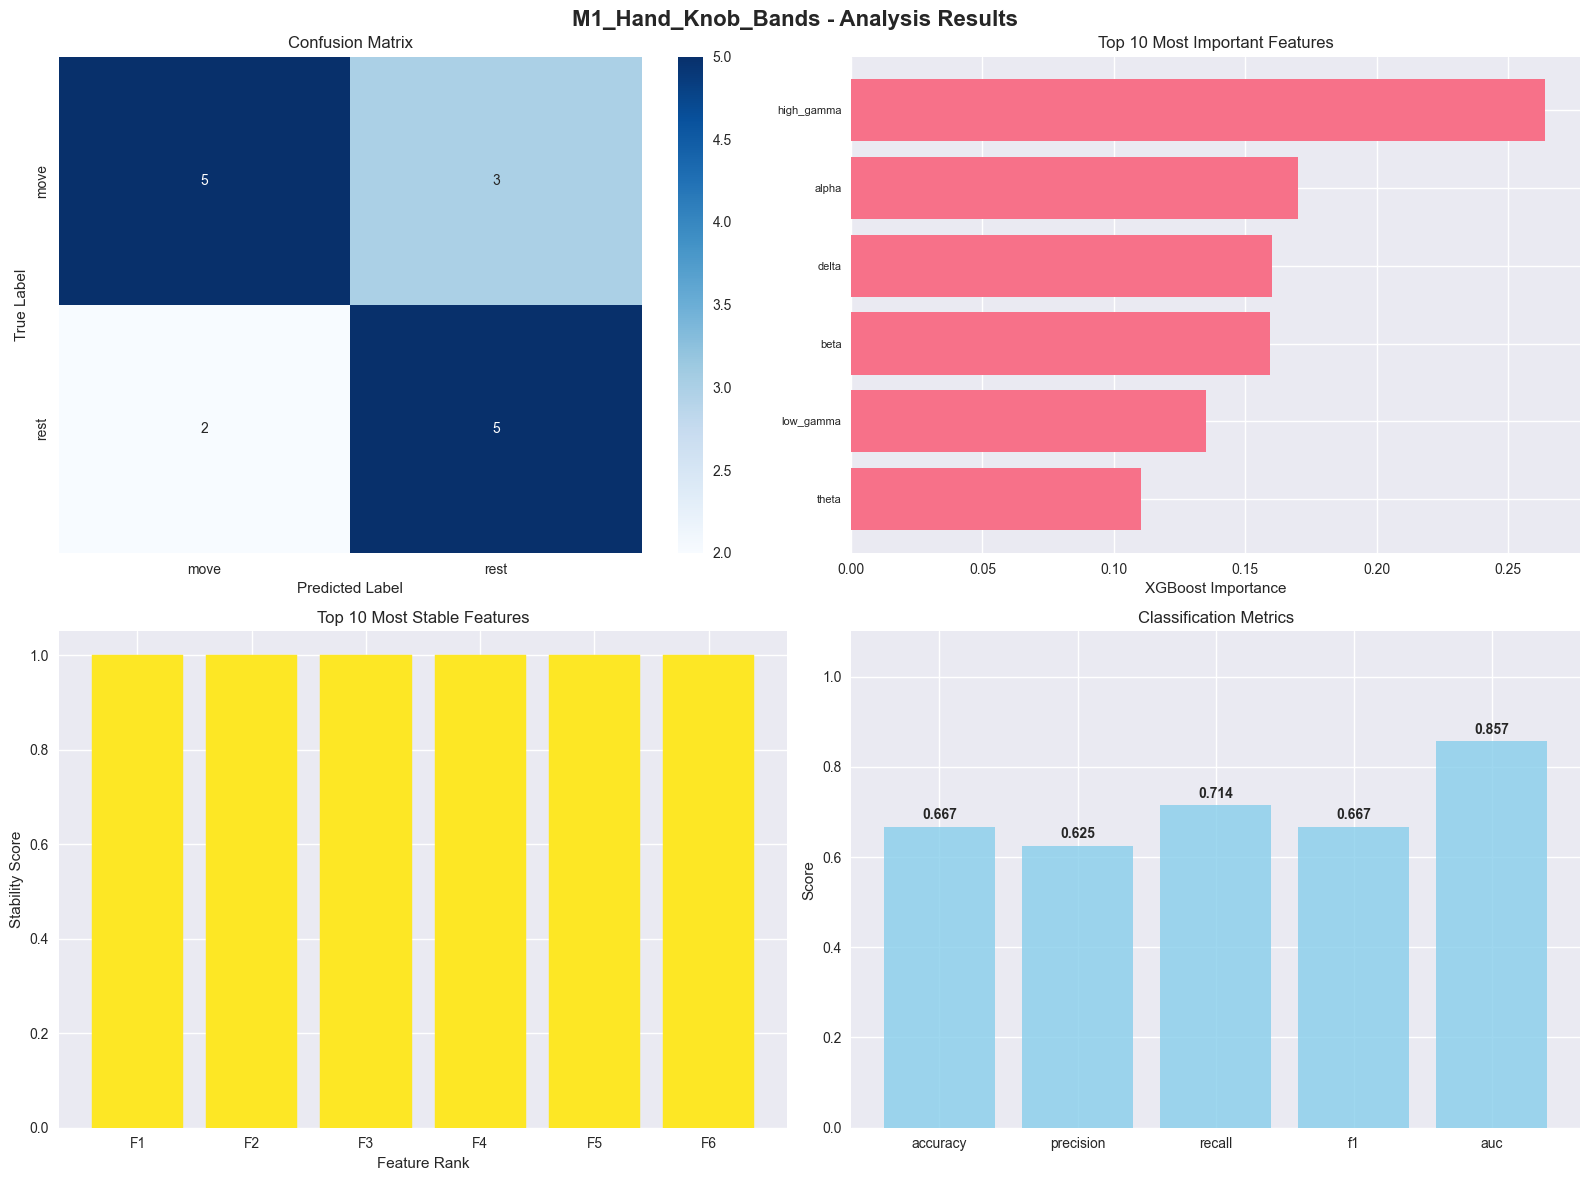

2026-05-14 14:01:39,191 - INFO - Plot saved to xgb_analysis_results\figures\M1_Hand_Knob_Bands_analysis.png
2026-05-14 14:01:39,242 - INFO - Analysis complete. Tables saved.



✅ Analysis Finished Successfully.
📊 Metrics: {'accuracy': 0.6666666666666666, 'precision': 0.625, 'recall': 0.7142857142857143, 'f1': 0.6666666666666666, 'auc': 0.8571428571428572}


In [1]:
import pandas as pd
import numpy as np
import os
import warnings
from pathlib import Path
from datetime import datetime
import logging
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess

# Core ML libraries
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder

# ──────────────────────────────────────────────────────────────────────────────
# 1. CONFIGURATION & SETUP
# ──────────────────────────────────────────────────────────────────────────────

# Suppress warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Global Configuration for Output
OUTPUT_DIR = Path("./xgb_analysis_results")
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

# Create directories if they don't exist
for dir_path in [OUTPUT_DIR, FIGURES_DIR, TABLES_DIR]:
    dir_path.mkdir(parents=True, exist_ok=True)

# Setup basic logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Global Parameters
RANDOM_STATE = 42
N_RUNS_STABILITY = 50
TOP_K_FEATURES = 15

# ──────────────────────────────────────────────────────────────────────────────
# 2. DATA LOADING & PREPARATION (Specific to M1 Hand Knob Data)
# ──────────────────────────────────────────────────────────────────────────────

# Define paths
DATA_INPUT_DIR = Path("./processed_data")
FEATURES_FILE = DATA_INPUT_DIR / "M1_Hand_Knob_ML_Features.csv"

RUN_NAME = "M1_Hand_Knob_Bands"

logger.info(f"Loading data from {FEATURES_FILE}...")

if not FEATURES_FILE.exists():
    raise FileNotFoundError(f"Could not find {FEATURES_FILE}. Please run the signal processing script first.")

# Load the merged DataFrame
df = pd.read_csv(FEATURES_FILE)

# Inspect target distribution
logger.info(f"Target distribution:\n{df['target'].value_counts()}")

# Define Target and Features
TARGET_COL = 'target'
EPOCH_COL = 'epoch' # We usually drop epoch ID as it's not a predictive feature

# Identify feature columns (all columns except target and epoch)
feature_columns = [col for col in df.columns if col not in [TARGET_COL, EPOCH_COL]]

# Extract X and y
X = df[feature_columns].values
y = df[TARGET_COL].values
feature_names = feature_columns

logger.info(f"Data loaded: {X.shape[0]} samples, {X.shape[1]} features.")

# ──────────────────────────────────────────────────────────────────────────────
# 3. UTILITY: GPU CHECK
# ──────────────────────────────────────────────────────────────────────────────

logger.info("Checking for GPU availability...")
gpu_available = False
try:
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    if result.returncode == 0:
        gpu_available = True
        logger.info("GPU detected (CUDA available).")
    else:
        logger.info("No GPU detected. Using CPU.")
except Exception:
    logger.info("Could not check GPU. Using CPU.")

device = 'cuda' if gpu_available else 'cpu'

# ──────────────────────────────────────────────────────────────────────────────
# 4. PREPROCESSING & TRAIN/TEST SPLIT
# ──────────────────────────────────────────────────────────────────────────────

logger.info(f"Starting analysis for: {RUN_NAME}")

# Encode Labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded,
    random_state=RANDOM_STATE
)

logger.info(f"Training set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")

# ──────────────────────────────────────────────────────────────────────────────
# 5. MODEL TRAINING (MAIN RUN)
# ──────────────────────────────────────────────────────────────────────────────

logger.info(f"Training XGBoost model on {device.upper()}...")

clf = XGBClassifier(
    objective='binary:logistic', # Works for binary classification (Rest vs Move)
    eval_metric='logloss',
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='hist',
    device=device,
    verbosity=0
)

clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

# ──────────────────────────────────────────────────────────────────────────────
# 6. EVALUATION METRICS
# ──────────────────────────────────────────────────────────────────────────────

metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1': f1_score(y_test, y_pred, zero_division=0),
    'auc': roc_auc_score(y_test, y_proba) if len(np.unique(y_encoded)) > 1 else 0.5
}

# Cross-Validation
logger.info("Performing Cross-Validation...")
cv_scores = cross_val_score(
    clf, X, y_encoded, 
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy', n_jobs=-1
)

# Feature Importance (Single Run)
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)

logger.info(f"--- Results for {RUN_NAME} ---")
for k, v in metrics.items():
    logger.info(f"{k.capitalize()}: {v:.3f}")
logger.info(f"CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# ──────────────────────────────────────────────────────────────────────────────
# 7. FEATURE STABILITY ANALYSIS (LOOP)
# ──────────────────────────────────────────────────────────────────────────────

logger.info(f"Computing feature stability ({N_RUNS_STABILITY} runs)...")

feature_counts = {name: 0 for name in feature_names}
all_importances_list = []

for i in range(N_RUNS_STABILITY):
    # Split data with different seed for each run
    X_train_stab, X_test_stab, y_train_stab, y_test_stab = train_test_split(
        X, y_encoded, test_size=0.2, stratify=y_encoded,
        random_state=RANDOM_STATE + i
    )
    
    # Initialize model for stability run
    clf_stab = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=RANDOM_STATE + i,
        n_jobs=1, # Single job to avoid overhead in loop
        tree_method='hist',
        device=device,
        verbosity=0
    )
    
    clf_stab.fit(X_train_stab, y_train_stab)
    
    # Get top K features for this run
    imp_df_run = pd.DataFrame({
        'feature': feature_names,
        'importance': clf_stab.feature_importances_,
        'run': i
    }).sort_values('importance', ascending=False).head(TOP_K_FEATURES)
    
    all_importances_list.append(imp_df_run)
    
    # Increment count for selected features
    for feature in imp_df_run['feature']:
        if feature in feature_counts:
            feature_counts[feature] += 1

    # Progress log every 10 runs
    if (i + 1) % 10 == 0:
        logger.info(f"Stability run {i + 1}/{N_RUNS_STABILITY} complete.")

# Compile stability results
all_imp_concat = pd.concat(all_importances_list, ignore_index=True)

stability_data = []
for feat, count in feature_counts.items():
    stability_data.append({
        'feature': feat,
        'stability_score': count / N_RUNS_STABILITY,
        'selection_frequency': count
    })
    
stability_df = pd.DataFrame(stability_data).sort_values('stability_score', ascending=False)

# Add mean importance across all runs where the feature was selected
mean_imp = all_imp_concat.groupby('feature')['importance'].mean()
stability_df['mean_importance'] = stability_df['feature'].map(mean_imp).fillna(0)

logger.info("Stability analysis complete.")

# ──────────────────────────────────────────────────────────────────────────────
# 8. VISUALIZATION
# ──────────────────────────────────────────────────────────────────────────────

logger.info("Generating plots...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'{RUN_NAME} - Analysis Results', fontsize=16, fontweight='bold')

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=le.classes_,
           yticklabels=le.classes_, ax=axes[0,0])
axes[0,0].set_title('Confusion Matrix')
axes[0,0].set_ylabel('True Label')
axes[0,0].set_xlabel('Predicted Label')

# 2. Top 10 Feature Importances
top_features = importance_df.head(10)
axes[0,1].barh(range(len(top_features)), top_features['importance'])
axes[0,1].set_yticks(range(len(top_features)))
# Truncate long feature names for display
labels = [f[:30] + '...' if len(f) > 30 else f for f in top_features['feature']]
axes[0,1].set_yticklabels(labels, fontsize=8)
axes[0,1].set_xlabel('XGBoost Importance')
axes[0,1].set_title('Top 10 Most Important Features')
axes[0,1].invert_yaxis()

# 3. Feature Stability
stable_features = stability_df.head(10)
bars = axes[1,0].bar(range(len(stable_features)), stable_features['stability_score'])
axes[1,0].set_xlabel('Feature Rank')
axes[1,0].set_ylabel('Stability Score')
axes[1,0].set_title('Top 10 Most Stable Features')
axes[1,0].set_xticks(range(len(stable_features)))
axes[1,0].set_xticklabels([f"F{i+1}" for i in range(len(stable_features))])

# Color bars by stability score
for bar, score in zip(bars, stable_features['stability_score']):
    bar.set_color(plt.cm.viridis(score))

# 4. Performance Metrics
metric_names = list(metrics.keys())
metric_values = list(metrics.values())
bars = axes[1,1].bar(metric_names, metric_values, color='skyblue', alpha=0.8)
axes[1,1].set_ylabel('Score')
axes[1,1].set_title('Classification Metrics')
axes[1,1].set_ylim(0, 1.1) # Slightly higher to accommodate text

for bar, value in zip(bars, metric_values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()

# Save Figure
save_path = FIGURES_DIR / f'{RUN_NAME}_analysis.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
logger.info(f"Plot saved to {save_path}")

# ──────────────────────────────────────────────────────────────────────────────
# 9. SAVE TABLES
# ──────────────────────────────────────────────────────────────────────────────

stability_df.head(20).to_csv(TABLES_DIR / f'{RUN_NAME}_stability.csv', index=False)
importance_df.head(20).to_csv(TABLES_DIR / f'{RUN_NAME}_importance.csv', index=False)

logger.info("Analysis complete. Tables saved.")

# ──────────────────────────────────────────────────────────────────────────────
# 10. FINAL RESULT OBJECT (Optional for inspection)
# ──────────────────────────────────────────────────────────────────────────────

results = {
    'run_name': RUN_NAME,
    'model': clf,
    'metrics': metrics,
    'cv_scores': cv_scores,
    'importance': importance_df,
    'stability': stability_df,
    'label_encoder': le,
    'test_data': (X_test, y_test, y_pred)
}

print("\n✅ Analysis Finished Successfully.")
print(f"📊 Metrics: {metrics}")